# Train LSTM

This notebook trains a stock-only LSTM baseline.

Split:
- train: 2010–2018
- validation: 2019–2021
- test: 2022–2026

Results are saved under `outputs/figures` and `outputs/metrics`.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.dataset import StockSequenceDataset, print_dataset_summary
from src.models import build_model, count_parameters

def rel_path(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()

print("Setup complete.")
print("CUDA available:", torch.cuda.is_available())

Setup complete.
CUDA available: True


## Config

In [2]:
CSV_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"

TRAIN_END = "2018-12-31"
VAL_END = "2021-12-31"

MODEL_TYPE = "LSTM"
EXPERIMENT_NAME = "lstm"

LOOKBACK = 30
NUM_CLASSES = 3
LABEL_NAMES = ["down", "flat", "up"]

HIDDEN_DIM = 64
NUM_LAYERS = 1
DROPOUT = 0.2
BIDIRECTIONAL = False

BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
EPOCHS = 5
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = 1.0

MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CSV exists:", CSV_PATH.exists())
print("Model:", MODEL_TYPE)
print("Device:", DEVICE)

CSV exists: True
Model: LSTM
Device: cuda


## Seed

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

## Load data

In [4]:
train_dataset = StockSequenceDataset(str(CSV_PATH), split="train", lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)
val_dataset = StockSequenceDataset(str(CSV_PATH), split="val", lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)
test_dataset = StockSequenceDataset(str(CSV_PATH), split="test", lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)

print_dataset_summary(train_dataset, "Train Dataset")
print_dataset_summary(val_dataset, "Validation Dataset")
print_dataset_summary(test_dataset, "Test Dataset")

INPUT_DIM = train_dataset.X.shape[-1]
print("INPUT_DIM:", INPUT_DIM)

[train] Number of feature columns: 13
[train] Feature columns: ['daily_return', 'log_return', 'open_close_return', 'high_low_range', 'volume_change', 'ma_5_ratio', 'ma_10_ratio', 'ma_20_ratio', 'volatility_5', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']
[val] Number of feature columns: 13
[val] Feature columns: ['daily_return', 'log_return', 'open_close_return', 'high_low_range', 'volume_change', 'ma_5_ratio', 'ma_10_ratio', 'ma_20_ratio', 'volatility_5', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']
[test] Number of feature columns: 13
[test] Feature columns: ['daily_return', 'log_return', 'open_close_return', 'high_low_range', 'volume_change', 'ma_5_ratio', 'ma_10_ratio', 'ma_20_ratio', 'volatility_5', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']
Train Dataset
Number of samples: 1005533
X shape: (1005533, 30, 13)
y shape: (1005533,)
Target distribution:
  0: 312017 (31.03%)
  1: 283953 (28.24%)
  2: 409563 (40.73%)
Date range:
201

## DataLoaders

In [5]:
def maybe_subset(dataset, max_samples, seed=42):
    if max_samples is None or len(dataset) <= max_samples:
        return dataset
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(dataset), size=max_samples, replace=False)
    return Subset(dataset, np.sort(idx).tolist())

train_data = maybe_subset(train_dataset, MAX_TRAIN_SAMPLES, SEED)
val_data = maybe_subset(val_dataset, MAX_VAL_SAMPLES, SEED)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("Train samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_dataset))

Train samples: 1005533
Validation samples: 368455
Test samples: 541680


## Build model

In [6]:
model = build_model(
    model_type=MODEL_TYPE,
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(model)
print("Trainable parameters:", count_parameters(model))

RecurrentClassifier(
  (rnn): LSTM(13, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=64, out_features=3, bias=True)
  )
)
Trainable parameters: 20419


## Helper functions

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip_norm=None):
    model.train()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for X, y in tqdm(loader, desc="Training", leave=False):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        optimizer.step()

        total_loss += loss.item() * X.size(0)
        all_preds.append(torch.argmax(logits, dim=1).detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    return (
        total_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
    )


@torch.no_grad()
def evaluate_with_probs(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_targets, all_preds, all_probs = [], [], []

    for X, y in tqdm(loader, desc="Evaluating", leave=False):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)
        loss = criterion(logits, y)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() * X.size(0)
        all_targets.append(y.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)

    return (
        total_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
        y_true,
        y_pred,
        probs,
    )


def plot_confusion_matrix(cm, title, save_path, labels):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(ticks=np.arange(len(labels)), labels=labels)
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

## Train

In [8]:
history = []
best_state = None
best_val_macro_f1 = -1.0
best_epoch = None

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, GRAD_CLIP_NORM
    )

    val_loss, val_acc, val_macro_f1, val_weighted_f1, y_val_true, y_val_pred, val_probs = evaluate_with_probs(
        model, val_loader, criterion, DEVICE
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_macro_f1": train_macro_f1,
        "train_weighted_f1": train_weighted_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
    })

    print(f"train_loss={train_loss:.4f} | train_macro_f1={train_macro_f1:.4f}")
    print(f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f}")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

print(f"\nTraining time: {time.time() - start_time:.2f} seconds")
history_df = pd.DataFrame(history)
history_df


Epoch 1/5


Training:   0%|          | 0/982 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

train_loss=1.0731 | train_macro_f1=0.2662
val_loss=1.0523 | val_macro_f1=0.2766

Epoch 2/5


Training:   0%|          | 0/982 [00:00<?, ?it/s]

...

train_loss=1.0649 | train_macro_f1=0.3182
val_loss=1.0593 | val_macro_f1=0.3151

Epoch 5/5


Training:   0%|          | 0/982 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

train_loss=1.0623 | train_macro_f1=0.3331
val_loss=1.0597 | val_macro_f1=0.2818

Training time: 87.12 seconds


,epoch,train_loss,train_acc,train_macro_f1,train_weighted_f1,val_loss,val_acc,val_macro_f1,val_weighted_f1
0,1,1.073058,0.412939,0.266239,0.297259,1.052297,0.442084,0.276594,0.330425
1,2,1.068329,0.418258,0.300356,0.326052,1.050247,0.446513,0.270214,0.325498
2,3,1.066724,0.419992,0.310709,0.335202,1.053875,0.442570,0.282317,0.333154
3,4,1.064857,0.421742,0.318210,0.341927,1.059316,0.439169,0.315079,0.357146
4,5,1.062339,0.424381,0.333135,0.355521,1.059660,0.434626,0.281840,0.336875


## Training curves

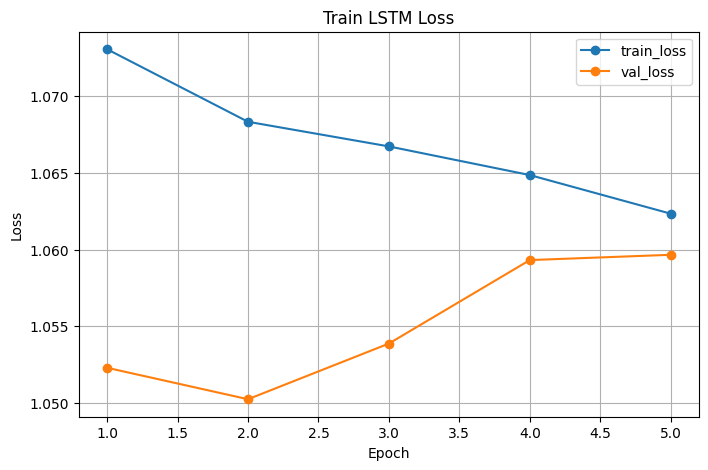

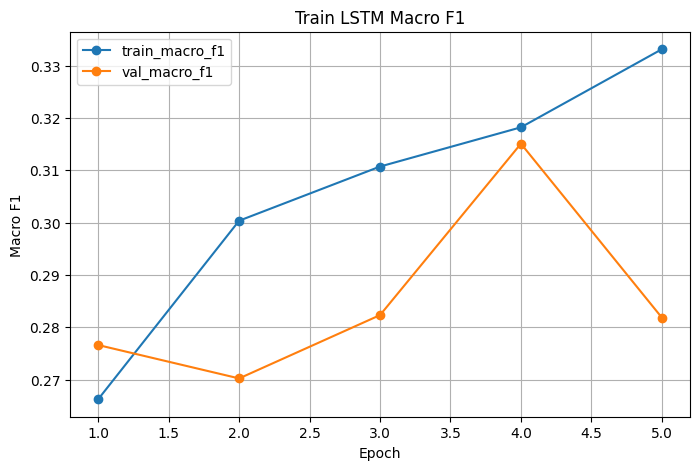

In [9]:
figures_dir = PROJECT_ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train LSTM Loss")
plt.legend()
plt.grid(True)
plt.savefig(figures_dir / "lstm_loss.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="train_macro_f1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Train LSTM Macro F1")
plt.legend()
plt.grid(True)
plt.savefig(figures_dir / "lstm_macro_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## Validation and test reports

In [10]:
model.load_state_dict(best_state)
print("Best epoch:", best_epoch)
print("Best validation macro F1:", best_val_macro_f1)

val_loss, val_acc, val_macro_f1, val_weighted_f1, y_val_true, y_val_pred, val_probs = evaluate_with_probs(
    model, val_loader, criterion, DEVICE
)

test_loss, test_acc, test_macro_f1, test_weighted_f1, y_test_true, y_test_pred, test_probs = evaluate_with_probs(
    model, test_loader, criterion, DEVICE
)

print("\nValidation")
print("Loss:", val_loss)
print("Accuracy:", val_acc)
print("Macro F1:", val_macro_f1)
print("Weighted F1:", val_weighted_f1)
print(classification_report(y_val_true, y_val_pred, target_names=LABEL_NAMES, digits=4))

print("\nTest")
print("Loss:", test_loss)
print("Accuracy:", test_acc)
print("Macro F1:", test_macro_f1)
print("Weighted F1:", test_weighted_f1)
print(classification_report(y_test_true, y_test_pred, target_names=LABEL_NAMES, digits=4))

val_cm = confusion_matrix(y_val_true, y_val_pred)
test_cm = confusion_matrix(y_test_true, y_test_pred)

Best epoch: 4
Best validation macro F1: 0.3150789446258134


Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/529 [00:00<?, ?it/s]


Validation
Loss: 1.059315525790321
Accuracy: 0.43916896228847485
Macro F1: 0.3150789446258134
Weighted F1: 0.35714618196009024
              precision    recall  f1-score   support

        down     0.3710    0.0735    0.1227    116598
        flat     0.3704    0.1703    0.2333     87428
          up     0.4534    0.8415    0.5893    164429

    accuracy                         0.4392    368455
   macro avg     0.3983    0.3617    0.3151    368455
weighted avg     0.4076    0.4392    0.3571    368455


Test
Loss: 1.0644962794917001
Accuracy: 0.41180770934869293
Macro F1: 0.26598328036508895
Weighted F1: 0.3005553617628535
              precision    recall  f1-score   support

        down     0.3860    0.0505    0.0893    194942
        flat     0.3324    0.0867    0.1376    121382
          up     0.4184    0.8995    0.5711    225356

    accuracy                         0.4118    541680
   macro avg     0.3789    0.3456    0.2660    541680
weighted avg     0.3874    0.4118    0.300

## Save results

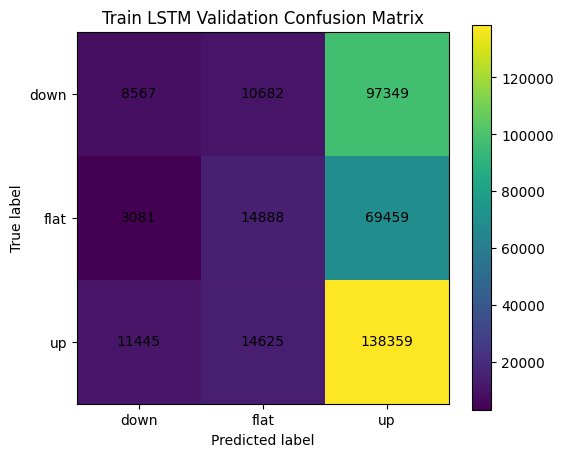

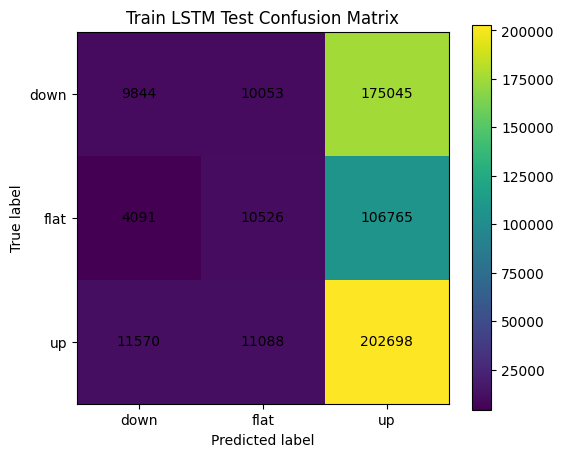

Saved: outputs/metrics/lstm_summary.csv


,model,split,loss,accuracy,macro_f1,weighted_f1,down_f1,flat_f1,up_f1,best_epoch,input_dim,hidden_dim,num_layers,dropout,learning_rate
0,lstm,validation,1.059316,0.439169,0.315079,0.357146,0.122656,0.233312,0.589268,4,13,64,1,0.2,0.001
1,lstm,test,1.064496,0.411808,0.265983,0.300555,0.089309,0.137551,0.571090,4,13,64,1,0.2,0.001


In [11]:
metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
figures_dir = PROJECT_ROOT / "outputs" / "figures"
metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

plot_confusion_matrix(val_cm, "Train LSTM Validation Confusion Matrix", figures_dir / "lstm_val_confusion_matrix.png", LABEL_NAMES)
plot_confusion_matrix(test_cm, "Train LSTM Test Confusion Matrix", figures_dir / "lstm_test_confusion_matrix.png", LABEL_NAMES)

history_df.to_csv(metrics_dir / "lstm_history.csv", index=False)

val_report = classification_report(y_val_true, y_val_pred, target_names=LABEL_NAMES, output_dict=True, digits=4)
test_report = classification_report(y_test_true, y_test_pred, target_names=LABEL_NAMES, output_dict=True, digits=4)

summary_df = pd.DataFrame([
    {
        "model": EXPERIMENT_NAME,
        "split": "validation",
        "loss": val_loss,
        "accuracy": val_acc,
        "macro_f1": val_macro_f1,
        "weighted_f1": val_weighted_f1,
        "down_f1": val_report["down"]["f1-score"],
        "flat_f1": val_report["flat"]["f1-score"],
        "up_f1": val_report["up"]["f1-score"],
        "best_epoch": best_epoch,
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE,
    },
    {
        "model": EXPERIMENT_NAME,
        "split": "test",
        "loss": test_loss,
        "accuracy": test_acc,
        "macro_f1": test_macro_f1,
        "weighted_f1": test_weighted_f1,
        "down_f1": test_report["down"]["f1-score"],
        "flat_f1": test_report["flat"]["f1-score"],
        "up_f1": test_report["up"]["f1-score"],
        "best_epoch": best_epoch,
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE,
    },
])

summary_path = metrics_dir / "lstm_summary.csv"
summary_df.to_csv(summary_path, index=False)

if EXPERIMENT_NAME == "gru_weighted":
    summary_df.to_csv(metrics_dir / "gru_weighted_validation_vs_test.csv", index=False)

pd.DataFrame(val_cm, index=["true_down", "true_flat", "true_up"], columns=["pred_down", "pred_flat", "pred_up"]).to_csv(metrics_dir / "lstm_val_confusion_matrix.csv")
pd.DataFrame(test_cm, index=["true_down", "true_flat", "true_up"], columns=["pred_down", "pred_flat", "pred_up"]).to_csv(metrics_dir / "lstm_test_confusion_matrix.csv")

print("Saved:", rel_path(summary_path))
summary_df